# Análisis estratégico y clustering de cartas: Wingspan

**Proyecto final — Diplomado en Transformación Digital Empresarial**  
**Autora:** Marcela Cadena  
**Fecha:** Junio 2026

---

## Pregunta de investigación

> ¿Qué grupos naturales emergen de los textos de poder de las cartas de Wingspan, y cómo se relacionan esos grupos con el tipo de activación, las mecánicas especiales y el hábitat del ave?

**Motivación estratégica:** Cada carta de Wingspan tiene un poder descrito en texto libre. Ese texto contiene la esencia estratégica de la carta: qué hace, cuándo lo hace y qué recursos mueve. Si agrupamos las cartas según la similitud de sus poderes, podemos descubrir patrones que las reglas del juego no explicitan — y usarlos para tomar mejores decisiones en el *draft* inicial.

---

**Estructura del notebook:**
1. Problema y datos (15%)
2. Modelado y análisis (35%)
3. Interpretación de clusters (25%)
4. Conclusiones (15%)
5. Uso de IA (10%)

---
## 1. Problema y datos
### 1.1 Carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'raw', 'wingspan-20260128.xlsx')

# Las filas 1 y 2 del Excel contienen estadísticas internas, no cartas.
df_raw = pd.read_excel(DATA_PATH, sheet_name='Birds', skiprows=[1, 2])

print(f'Dimensiones del dataset: {df_raw.shape}')
df_raw.head(3)

Dimensiones del dataset: (707, 65)


,Common name,Scientific name,Set,Color,Power text,Predator,Flocking,Bonus card,Victory points,Nest type,...,Nest Box Builder,Omnivore Expert,Passerine Specialist,Platform Builder,Prairie Manager,Rodentologist,Small Clutch Specialist,Viticulturalist,Wetland Scientist,Wildlife Gardener
0,Abbott's Booby,Papasula abbotti,oceania,white,"Draw 3 bonus cards, then discard 2. You may di...",NaN,NaN,X,5,platform,...,NaN,NaN,NaN,X,NaN,NaN,X,NaN,X,NaN
1,Acadian Flycatcher,Empidonax virescens,promoUS,brown,Draw and discard 1 [card] from the deck. If it...,NaN,NaN,NaN,2,wild,...,X,NaN,X,X,NaN,NaN,X,NaN,NaN,X
2,Acorn Woodpecker,Melanerpes formicivorus,core,brown,"Gain 1 [seed] from the birdfeeder, if availabl...",NaN,NaN,NaN,5,cavity,...,X,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Exploración del campo `Power text`

In [3]:
# Eliminar filas sin nombre de ave
df = df_raw.dropna(subset=['Common name']).reset_index(drop=True)
print(f'Total de cartas: {len(df)}')

# Cartas con y sin poder
con_poder = df['Power text'].notna().sum()
sin_poder = df['Power text'].isna().sum()
print(f'Cartas con Power text:  {con_poder} ({con_poder/len(df)*100:.1f}%)')
print(f'Cartas sin Power text:  {sin_poder} ({sin_poder/len(df)*100:.1f}%)')

Total de cartas: 707
Cartas con Power text:  701 (99.2%)
Cartas sin Power text:  6 (0.8%)


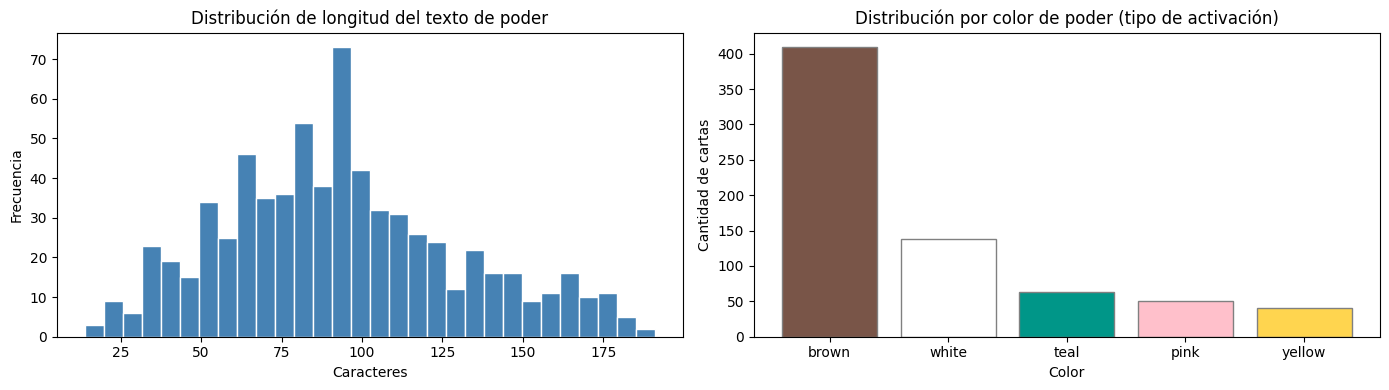

In [4]:
# Longitud del texto de poder
df['power_length'] = df['Power text'].fillna('').apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[df['power_length'] > 0]['power_length'], bins=30,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud del texto de poder')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

color_counts = df['Color'].value_counts()
axes[1].bar(color_counts.index, color_counts.values,
            color=['#795548', '#FFFFFF', '#009688', '#FFC0CB', '#FFD54F'],
            edgecolor='gray')
axes[1].set_title('Distribución por color de poder (tipo de activación)')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Cantidad de cartas')

plt.tight_layout()
plt.show()

En Wingspan cada color indica cuándo se activa el poder de la carta:

| Color | Cuándo se activa | Ejemplo de poder |
| :--- | :--- | :--- |
| <strong style="color: #795548;">Marrón (Brown)</strong> | Cada vez que activas el hábitat donde está el ave | "Lay 1 egg on each bird in this habitat" |
| <strong style="color: #FFC0CB;">Rosa (Pink)</strong> | Una vez entre turnos, cuando otro jugador activa ese hábitat | "When another player plays a bird here, gain 1 food" |
| <strong style="color: #FFFFFF; background-color: #9E9E9E; padding: 2px 4px; border-radius: 3px;">Blanco (White)</strong> | Solo al momento de jugar la carta, una única vez | "Draw 3 bonus cards, then discard 2" |
| <strong style="color: #009688;">Verde azulado (Teal)</strong> | Al final de cada ronda | "Tuck 1 card from your hand behind this bird" |
| <strong style="color: #FFD54F;">Amarillo (Yellow)</strong> | Al final de la partida | "Calculate score for this bird based on eggs in its habitat" |
| **Sin color** | Nunca — es información pasiva | Solo indica puntos base o condiciones de bonificación |

---

**Importante considerar:**

- Las cartas <strong style="color: #795548;">marrón</strong> son el corazón de cualquier motor porque su poder se repite múltiples veces por partida — cuanto más a la izquierda estén en el tablero, más veces se activan. 
- Las <strong style="color: #FFC0CB;">rosa</strong> acumulan recursos pasivamente sin gastar tu turno. 
- Las <strong style="color: #FFFFFF; background-color: #9E9E9E; padding: 2px 4px; border-radius: 3px;">blanco</strong> y <strong style="color: #009688;">verde azulado</strong> son poderes de apoyo, no de motor. 
- Finalmente, las cartas <strong style="color: #FFD54F;">amarillo</strong> te permiten capitalizar estrategias y obtener puntos masivos al terminar el juego.

In [5]:
# Resumen: distribución por color en cada Set
from IPython.display import display

counts = df.groupby(['Set', 'Color']).size().unstack(fill_value=0)
counts['Total'] = counts.sum(axis=1)

pct = counts.div(counts['Total'], axis=0).multiply(100).round(1)

color_cols = [c for c in counts.columns if c != 'Total']
formatted = counts[color_cols].astype(str) + ' (' + pct[color_cols].astype(str) + '%)'
formatted['Total'] = counts['Total']

formatted = formatted.sort_values('Total', ascending=False)

# Quitar el título "Color" que aparece sobre las columnas
formatted.columns.name = None

print("Distribución por Color dentro de cada Set (conteo (porcentaje%))\n")
display(formatted.reset_index())


Distribución por Color dentro de cada Set (conteo (porcentaje%))



,Set,brown,pink,teal,white,yellow,Total
0,core,125 (71.8%),12 (6.9%),0 (0.0%),37 (21.3%),0 (0.0%),174
1,americas,67 (60.4%),11 (9.9%),12 (10.8%),16 (14.4%),5 (4.5%),111
2,oceania,59 (62.1%),5 (5.3%),0 (0.0%),15 (15.8%),16 (16.8%),95
3,asia,54 (60.0%),2 (2.2%),16 (17.8%),15 (16.7%),3 (3.3%),90
4,european,38 (46.9%),5 (6.2%),20 (24.7%),18 (22.2%),0 (0.0%),81
5,promoAsia,12 (48.0%),2 (8.0%),2 (8.0%),6 (24.0%),3 (12.0%),25
6,promoCA,12 (48.0%),2 (8.0%),3 (12.0%),6 (24.0%),2 (8.0%),25
7,promoEurope,11 (44.0%),3 (12.0%),3 (12.0%),5 (20.0%),3 (12.0%),25
8,promoNZ,11 (44.0%),2 (8.0%),1 (4.0%),9 (36.0%),2 (8.0%),25
9,promoUK,8 (32.0%),4 (16.0%),4 (16.0%),5 (20.0%),4 (16.0%),25


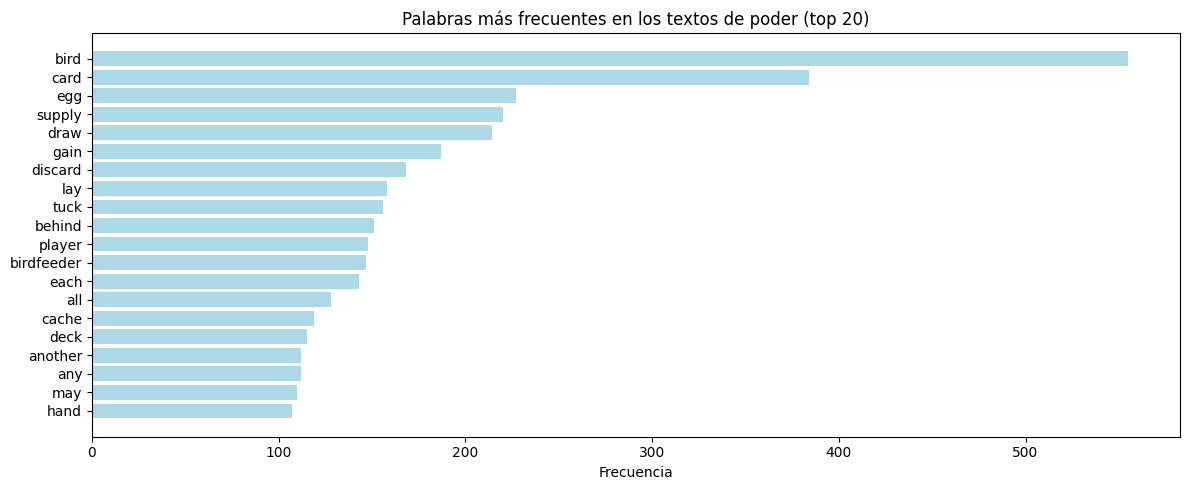

In [6]:
# Palabras más frecuentes en los textos de poder
from collections import Counter

# Palabras vacías a ignorar (stop words del dominio)
stop_words = {
      'the', 'a', 'an', 'this', 'that', 'of', 'in', 'on', 'to', 'from',
      'for', 'with', 'and', 'you', 'your', 'it', 'its', 'at', 'than',
      'then', 'is', 'are', 'be', 'as', 'up', 'per'
  }

all_words = []
for text in df['Power text'].dropna():
    words = re.findall(r'[a-z]+', text.lower())
    all_words.extend([w for w in words if w not in stop_words and len(w) > 2])

top_words = Counter(all_words).most_common(20)
words, counts = zip(*top_words)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(list(reversed(words)), list(reversed(counts)), color='lightblue')
ax.set_title('Palabras más frecuentes en los textos de poder (top 20)')
ax.set_xlabel('Frecuencia')
plt.tight_layout()
plt.show()

 **Una definicion importante:**
 
 Un **motor** en Wingspan es una estrategia de combo que un jugador construye a lo largo de la partida al colocar aves cuyo poderes se encadenan entre sí. Cada vez que activas un hábitat, las aves marrones (🟫) de esa fila se disparan en cascada de derecha a izquierda, generando recursos de forma exponencial. Un motor bien construido convierte cada turno en una cadena de acciones que produce más de lo que consume — huevos, alimento o cartas — creando una ventaja acumulativa que se vuelve difícil de remontar.
  
### Interpretación 

Las palabras más frecuentes revelan las mecánicas dominantes del juego: `egg`, `draw`, `food`, `cache`, `lay`, `tuck`. Estas son exactamente las acciones que definen los tres motores principales. 

La distribución de longitud del texto muestra que la mayoría de los poderes son descripciones cortas (menos de 150 caracteres), lo que sugiere vocabulario repetido y patrones claros para el clustering.

### 1.3 Limpieza y preparación del texto

In [7]:
def clean_power_text(text):
    if pd.isna(text):
        return ''
    # Minúsculas
    text = text.lower()
    # Reemplazar símbolos de recursos del juego por palabras legibles
    text = re.sub(r'\[invertebrate\]', 'invertebrate', text)
    text = re.sub(r'\[seed\]', 'seed', text)
    text = re.sub(r'\[fish\]', 'fish', text)
    text = re.sub(r'\[fruit\]', 'fruit', text)
    text = re.sub(r'\[rodent\]', 'rodent', text)
    text = re.sub(r'\[nectar\]', 'nectar', text)
    text = re.sub(r'\[wild\]', 'wild', text)
    text = re.sub(r'\[egg\]', 'egg', text)
    text = re.sub(r'\[card\]', 'card', text)
    # Eliminar caracteres no alfabéticos
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Colapsar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['power_clean'] = df['Power text'].apply(clean_power_text)

# Separar cartas con y sin poder para el análisis
df_con_poder = df[df['power_clean'] != ''].reset_index(drop=True)
df_sin_poder = df[df['power_clean'] == ''].reset_index(drop=True)

print(f'Cartas con poder (entran al clustering): {len(df_con_poder)}')
print(f'Cartas sin poder (excluidas del clustering): {len(df_sin_poder)}')
print(f'\nEjemplo de texto limpio:')
print(df_con_poder[['Common name', 'Power text', 'power_clean']].head(3).to_string())

Cartas con poder (entran al clustering): 701
Cartas sin poder (excluidas del clustering): 6

Ejemplo de texto limpio:
          Common name                                                                                                                                                                          Power text                                                                                                                                                        power_clean
0      Abbott's Booby                                                                                         Draw 3 bonus cards, then discard 2. You may discard bonus cards you did not draw this turn.                                                                               draw bonus cards then discard you may discard bonus cards you did not draw this turn
1  Acadian Flycatcher  Draw and discard 1 [card] from the deck. If it has [invertebrate] in its food cost, gain 1 [invertebrate] from the supply and cac

**Nota:** Las cartas sin poder son aves con valor puramente estático (solo suman puntos base al final). Se excluyen del clustering porque no aportan información textual, pero se analizan como grupo separado en la sección de interpretación.

## 2. Modelado y análisis
### 2.1 Vectorización con TF-IDF

Se vectoriza el campo de texto de los poderes con TF-IDF (Term Frequency — Inverse Document Frequency).

> **Explicación del Modelo: TF-IDF**
> 
> **TF-IDF** (*Term Frequency — Inverse Document Frequency*) es una técnica de vectorización de texto que convierte cada carta en un vector numérico. Asigna un peso alto a las palabras que son frecuentes en una carta específica pero raras en el resto del corpus — lo que las hace distintivas. 
> 
> En este análisis, una palabra como `cache` tendrá peso alto en las cartas que la usan porque no aparece en todas, mientras que palabras genéricas como `bird` se eliminan previamente. El resultado es una matriz donde cada fila es una carta y cada columna es una palabra, lista para ser procesada por los algoritmos de clustering.

Cada carta queda representada como un vector numérico donde cada dimensión es una palabra, ponderada por qué tan distintiva es en esa carta respecto al resto del corpus.

**Parámetros elegidos:**
- `max_features=200`: limita el vocabulario a las 200 características más informativas del corpus.
- `ngram_range=(1, 2)`: incluye unigramas, bigramas y trigramas (ej. `lay egg`, `draw cards`) que capturan mecánicas compuestas. ---> Le decimos al modelo algo como "Analiza el peso de cada palabra individual (1), pero también analiza el peso de cada par de palabras que aparezcan juntas (2)".
- `min_df=3`: ignora términos que aparecen en menos de 3 cartas (ruido).
- `sublinear_tf=True`: usa escala logaritmica para evitar que textos largos dominen. ---> En términos sencillos, significa que las primeras veces que aparece una palabra suman mucho valor, pero las repeticiones adicionales suman cada vez menos. Esto es importnte ya que en Wingspan, algunas aves tienen poderes muy sencillos y textos cortos, mientras que otras tienen condiciones complejas y textos largos.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 3),
    min_df=3,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df_con_poder['power_clean'])

print(f'Matriz TF-IDF: {X_tfidf.shape}')
print(f'  {X_tfidf.shape[0]} cartas x {X_tfidf.shape[1]} términos')
print('Primeros 30 términos del vocabulario:')
print(tfidf.get_feature_names_out()[:30])

Matriz TF-IDF: (701, 200)
  701 cartas x 200 términos
Primeros 30 términos del vocabulario:
['action' 'additional' 'all' 'all players' 'an' 'and' 'and discard'
 'and keep' 'another' 'another bird' 'another player' 'any' 'are' 'at'
 'at least' 'at the' 'at the end' 'available' 'behind' 'behind this'
 'behind this bird' 'bird' 'bird if' 'bird if you' 'bird in'
 'bird in your' 'bird with' 'birdfeeder' 'birdfeeder if' 'birds']


### 2.2 Reducción de dimensionalidad

Como es imposible visualizar agrupaciones en un espacio de 200 dimensiones, aplicamos una reducción de dimensionalidad en dos etapas:

- **PCA (Análisis de Componentes Principales):** Actúa como un filtro de ruido (paso previo). Reducimos el espacio a **50 dimensiones**, lo cual nos permite conservar aproximadamente el **83% de la varianza** original de los datos. 
Esta cantidad es ideal porque retiene la información de las mecánicas clave de las aves, al mismo tiempo que descarta el "ruido" matemático (palabras demasiado raras o mecánicas aisladas) antes de pasar al siguiente algoritmo.

- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** Comprime las 50 dimensiones obtenidas del PCA a un plano de **2 dimensiones** para poder graficarlas. Su principal fortaleza es que preserva las relaciones locales; en el contexto de *Wingspan*, esto garantiza que las aves con mecánicas de juego muy similares (como los motores de recolección de alimento o las estrategias de poner huevos) queden físicamente cerca unas de otras en la visualización. Es la herramienta ideal para revelar de forma gráfica las distintas sinergias y familias de cartas dentro del juego.

> **¿Es necesario estandarizar antes de PCA?**
>
> No en este caso. `TfidfVectorizer` aplica normalización L2 por defecto (`norm='l2'`), lo que significa que cada vector de carta ya tiene norma 1 — todas las cartas están en la misma escala antes de entrar a PCA.
>
> Aplicar `StandardScaler` sobre una matriz TF-IDF tendría un efecto negativo: centraría cada término en 0 convirtiendo los ceros (la mayoría de las celdas, dado el vocabulario disperso) en valores negativos, destruyendo la sparsity que hace eficiente el cálculo y distorsionando la geometría que PCA necesita para encontrar las direcciones de mayor varianza.

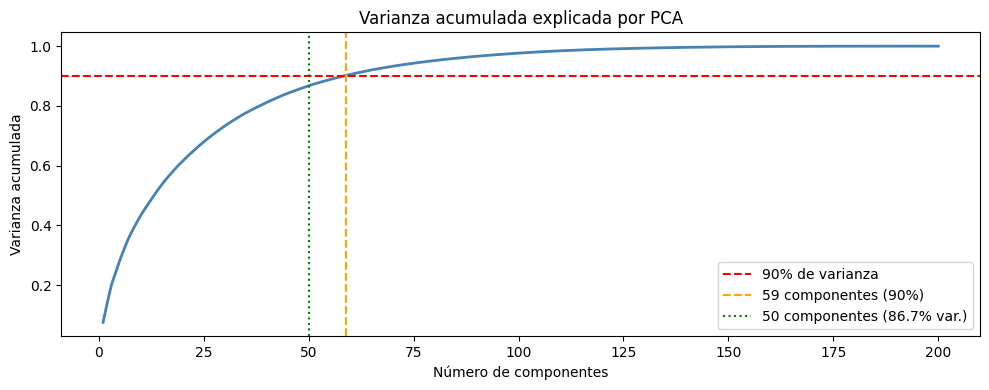

Componentes necesarios para alcanzar el 90% de varianza: 59
Varianza real retenida con 50 componentes: 86.74%


In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## Exploración...
pca_completo = PCA(random_state=RANDOM_STATE)
pca_completo.fit(X_tfidf.toarray())

varianza_acumulada = pca_completo.explained_variance_ratio_.cumsum()

componentes_90 = (varianza_acumulada >= 0.90).argmax() + 1
varianza_50 = varianza_acumulada[49] # Índice 49 corresponde a 50 componentes

### Gráfica
fig, ax = plt.subplots(figsize=(10, 4))

# Línea de la curva de varianza
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, color='steelblue', linewidth=2)

# Línea del objetivo del 90%
ax.axhline(0.90, color='red', linestyle='--', label='90% de varianza')

# Línea vertical donde realmente se alcanza el 90%
ax.axvline(componentes_90, color='orange', linestyle='--',
           label=f'{componentes_90} componentes (90%)')

# Línea vertical para tu límite original de 50 componentes
ax.axvline(50, color='green', linestyle=':', 
           label=f'50 componentes ({varianza_50:.1%} var.)')

ax.set_title('Varianza acumulada explicada por PCA')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.legend()
plt.tight_layout()
plt.show()


print(f'Componentes necesarios para alcanzar el 90% de varianza: {componentes_90}')
print(f'Varianza real retenida con 50 componentes: {varianza_50:.2%}')

## Decisión...
X_pca = PCA(n_components=50, random_state=RANDOM_STATE).fit_transform(X_tfidf.toarray())

### Configuración del modelo t-SNE
Para mapear las sinergias entre las cartas, configuramos el algoritmo t-SNE con los siguientes parámetros clave:

* **`n_components=2`:** Reduce las 50 dimensiones extraídas por el PCA a solo dos coordenadas (X, Y). Esto nos permite proyectar el motor de juego completo en un plano bidimensional (un mapa plano) donde cada punto representará un ave.
* **`perplexity=40`:** Es el parámetro que define el tamaño del "vecindario" de cada carta. Al ajustarlo a 40, le indicamos al algoritmo que cada ave debe buscar agruparse con aproximadamente 40 cartas de mecánicas afines. Para un mazo del tamaño de *Wingspan*, este valor es ideal para consolidar familias estratégicas lógicas (ej. motores de huevos o motores de robo) sin fragmentarlas en micro-grupos irrelevantes.
* **`max_iter=1000`:** Define el límite de tiempo que tiene el algoritmo para "jalonear" los datos. Le otorga hasta 1,000 repeticiones para que las fuerzas de atracción entre cartas similares estabilicen los clústeres en el mapa.
* **`random_state=RANDOM_STATE`:** Fija una semilla matemática inicial. Dado que t-SNE es un algoritmo estocástico (con un componente aleatorio), esto garantiza la **reproducibilidad** de nuestro análisis: el mapa de las aves se dibujará exactamente igual cada vez que ejecutemos el código.

In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px

# ── 1. Ajustar t-SNE sobre la matriz PCA 
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=RANDOM_STATE,
    max_iter=1000,
)
X_tsne = tsne.fit_transform(X_pca)

# ── 2. Agregar coordenadas al DataFrame 
df_con_poder['tsne_x'] = X_tsne[:, 0]
df_con_poder['tsne_y'] = X_tsne[:, 1]

# ── 3. Scatter interactivo con hover 
fig_tsne = px.scatter(               # nombre distinto para no pisar el fig de matplotlib
    df_con_poder,
    x='tsne_x',
    y='tsne_y',
    color='Color',                   # colorea por tipo de activación, no por cluster
    hover_name='Common name',        # aparece en negritas al hacer hover
    hover_data={
        'power_clean': True,         # muestra descripción del poder
        'tsne_x': False,             # oculta coordenadas brutas del hover
        'tsne_y': False,
    },
    title='Espacio t-SNE — hover para ver nombre y poder',
    color_discrete_map={            
        'brown':  '#795548',
        'pink':   '#E91E63',
        'white':  '#BDBDBD',
        'teal':   '#009688',
        'yellow': '#FFC107',
    },
    height=650,
)

fig_tsne.update_traces(marker=dict(size=7, opacity=0.75))
fig_tsne.update_layout(legend_title_text='Color de activación')
fig_tsne.show()

### Interpretación 

Recordemos que el algoritmo NO sabía de qué color eran las cartas cuando las agrupó. Las organizó basándose 100% en las palabras de sus poderes.

¿Qué observamos?
- Los puntos marrones están esparcidos por casi todo el mapa, formando múltiples clústeres diferentes (recordemos que son el motor del juego).
- Hay grupos definidos que se forman en los extremos izquierdos (tanto arriba como abajo) y son casi exclusivamente de puntos blancos o grises.
- Observamos los pequeños pero muy compactos grupos de puntos rosas (por ejemplo, en la parte superior central y en la parte inferior derecha).
- Las cartas amarillas de fin de partida (puntos dorados) tienden a agruparse en regiones específicas, probablemente porque comparten textos relacionados con conteos masivos (ej. "Count the number of birds...").
- Las verde azuladas (fin de ronda) están más dispersas, lo que indica que, al igual que las marrones, sus beneficios (robar, poner, cazar) son variados, aunque a veces se pegan a las islas marrones que hacen acciones similares.


### 2.3 K-means: elección del número de clusters

Se usa el **método del codo** (inercia) y el **silhouette score** para elegir .
El silhouette score mide qué tan bien separados están los clusters (1 = perfecto, -1 = solapados).

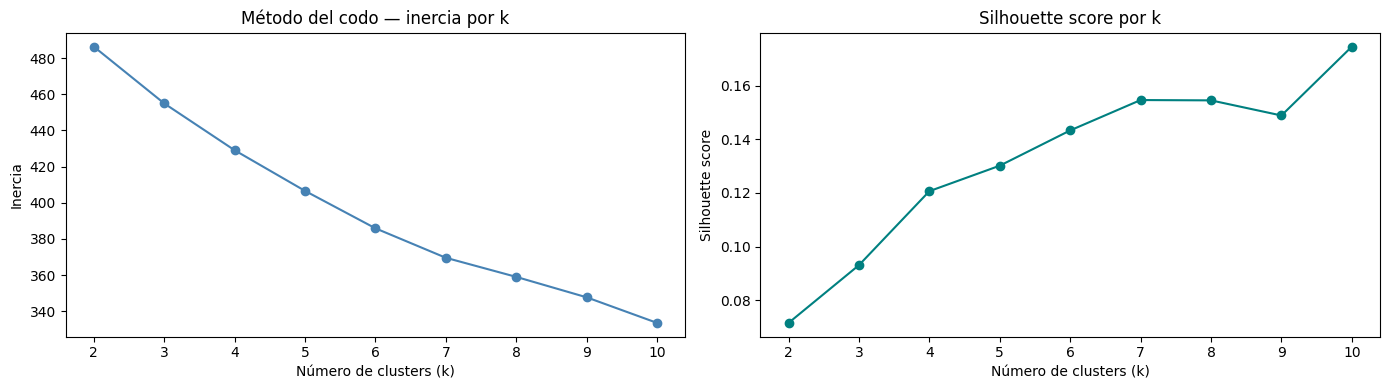

k con mejor silhouette score: 10 (0.1745)


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(k_range, inercias, marker='o', color='steelblue')
axes[0].set_title('Método del codo — inercia por k')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')

axes[1].plot(k_range, silhouettes, marker='o', color='teal')
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

mejor_k = k_range[silhouettes.index(max(silhouettes))]
print(f'k con mejor silhouette score: {mejor_k} ({max(silhouettes):.4f})')

### 2.4 K-means final

In [14]:
# Entrenar K-means con el k elegido
# Ajustar k_final según lo que muestren las gráficas anteriores
k_final = mejor_k

km_final = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=10)
df_con_poder['cluster_kmeans'] = km_final.fit_predict(X_pca)

print(f'Clusters K-means (k={k_final}):')
print(df_con_poder['cluster_kmeans'].value_counts().sort_index())

Clusters K-means (k=10):
cluster_kmeans
0     30
1     86
2    100
3     74
4     32
5     54
6     96
7     69
8     53
9    107
Name: count, dtype: int64


### 2.5 DBSCAN

In [15]:
from sklearn.cluster import DBSCAN

# DBSCAN sobre las 2 dimensiones de t-SNE (más intuitivo para comparar visualmente)
dbscan = DBSCAN(eps=3.0, min_samples=5)
df_con_poder['cluster_dbscan'] = dbscan.fit_predict(X_tsne)

n_clusters_db = len(set(df_con_poder['cluster_dbscan'])) - (1 if -1 in df_con_poder['cluster_dbscan'].values else 0)
n_ruido = (df_con_poder['cluster_dbscan'] == -1).sum()

print(f'Clusters encontrados por DBSCAN: {n_clusters_db}')
print(f'Puntos de ruido (etiqueta -1): {n_ruido} ({n_ruido/len(df_con_poder)*100:.1f}%)')
print(f'\nDistribución de clusters DBSCAN:')
print(df_con_poder['cluster_dbscan'].value_counts().sort_index())

Clusters encontrados por DBSCAN: 39
Puntos de ruido (etiqueta -1): 266 (37.9%)

Distribución de clusters DBSCAN:
cluster_dbscan
-1     266
 0       7
 1      13
 2       9
 3      29
 4       8
 5      12
 6       7
 7      18
 8      30
 9       8
 10     10
 11     12
 12      8
 13     28
 14      9
 15     26
 16      7
 17      9
 18      7
 19      6
 20     13
 21     28
 22      8
 23      8
 24      8
 25     14
 26     11
 27     14
 28      8
 29      6
 30     12
 31      5
 32      5
 33      6
 34      5
 35      5
 36      6
 37      5
 38      5
Name: count, dtype: int64


### 2.6 Comparación visual: K-means vs DBSCAN

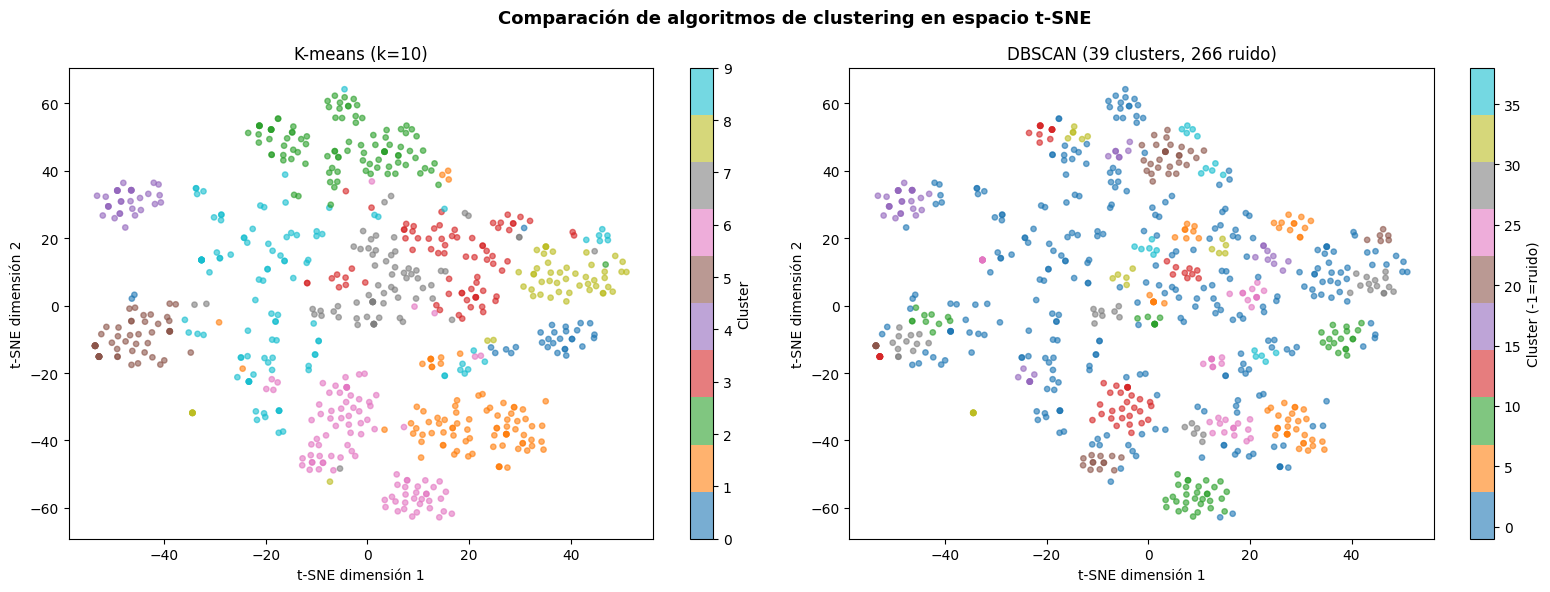

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de algoritmos de clustering en espacio t-SNE',
             fontsize=13, fontweight='bold')

# K-means
scatter1 = axes[0].scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_kmeans'], cmap='tab10', alpha=0.6, s=15
)
axes[0].set_title(f'K-means (k={k_final})')
axes[0].set_xlabel('t-SNE dimensión 1')
axes[0].set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# DBSCAN
scatter2 = axes[1].scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_dbscan'], cmap='tab10', alpha=0.6, s=15
)
axes[1].set_title(f'DBSCAN ({n_clusters_db} clusters, {n_ruido} ruido)')
axes[1].set_xlabel('t-SNE dimensión 1')
axes[1].set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster (-1=ruido)')

plt.tight_layout()
plt.show()

---
## 3. Interpretación de clusters

Se analizan los clusters de K-means (modelo elegido por cubrir todas las cartas).
Para cada cluster se identifican: las palabras más representativas, el perfil de
mecánicas (Color, Predator, Flocking) y el hábitat predominante.

### 3.1 Palabras más representativas por cluster

In [17]:
import numpy as np

# Obtener el centroide de cada cluster en el espacio TF-IDF
feature_names = tfidf.get_feature_names_out()
X_tfidf_dense = X_tfidf.toarray()

n_top = 10
print(f'Top {n_top} palabras por cluster (K-means, k={k_final}):')

for cluster_id in sorted(df_con_poder['cluster_kmeans'].unique()):
    indices = df_con_poder[df_con_poder['cluster_kmeans'] == cluster_id].index
    # Promedio TF-IDF de las cartas del cluster
    centroide = X_tfidf_dense[indices].mean(axis=0)
    top_idx = centroide.argsort()[::-1][:n_top]
    top_terms = ', '.join(feature_names[top_idx])
    n_cartas = len(indices)
    print(f'  Cluster {cluster_id} ({n_cartas} cartas): {top_terms}')

Top 10 palabras por cluster (K-means, k=10):
  Cluster 0 (30 cartas): die from, die from the, die, gain die from, gain die, from the birdfeeder, the birdfeeder, birdfeeder, gain, the
  Cluster 1 (86 cartas): your hand, from your hand, hand, card from your, from your, card, your hand behind, hand behind, your, hand behind this
  Cluster 2 (100 cartas): lay, lay egg, egg on, egg, lay egg on, on, bird, egg on this, egg on each, on each
  Cluster 3 (74 cartas): supply, gain, from the supply, the supply, from the, from, the, invertebrate, invertebrate from, invertebrate from the
  Cluster 4 (32 cartas): play, normal, its normal, pay its normal, pay its, its, cost, pay, bird in, bird in your
  Cluster 5 (54 cartas): bonus, new bonus, new, draw new bonus, draw new, bonus cards, cards, keep, draw, new bonus cards
  Cluster 6 (96 cartas): deck, the deck, from the deck, card from the, card from, card, from the, the, behind, from
  Cluster 7 (69 cartas): cache, supply on, supply on this, the supp

### 3.2 Perfil de mecánicas por cluster

In [18]:
# Preparar columnas binarias necesarias
for col in ['Predator', 'Flocking', 'Forest', 'Grassland', 'Wetland', 'Bonus card']:
    df_con_poder[col] = df_con_poder[col].apply(lambda x: 1 if x == 'X' else (1 if x == 1 else 0))

# Perfil numérico por cluster
perfil_cols = ['Victory points', 'Total food cost', 'Egg limit',
               'Forest', 'Grassland', 'Wetland',
               'Predator', 'Flocking', 'Bonus card']

perfil = df_con_poder.groupby('cluster_kmeans')[perfil_cols].mean().round(2)
perfil['n_cartas'] = df_con_poder['cluster_kmeans'].value_counts().sort_index()

print('Perfil promedio por cluster:')
print(perfil.to_string())

Perfil promedio por cluster:
                Victory points  Total food cost  Egg limit  Forest  Grassland  Wetland  Predator  Flocking  Bonus card  n_cartas
cluster_kmeans                                                                                                                  
0                         3.50             2.00       2.57    0.77       0.50     0.43      0.00      0.00        0.07        30
1                         3.58             1.95       2.93    0.47       0.45     0.62      0.09      0.73        0.01        86
2                         3.14             2.06       3.49    0.42       0.74     0.24      0.00      0.00        0.00       100
3                         4.00             1.95       2.74    0.74       0.36     0.34      0.04      0.00        0.00        74
4                         2.59             1.44       3.38    0.53       0.50     0.25      0.00      0.00        0.03        32
5                         5.20             2.48       2.41    0.39  

In [19]:
# Color predominante por cluster
color_por_cluster = (
    df_con_poder.groupby(['cluster_kmeans', 'Color'])
    .size()
    .unstack(fill_value=0)
)
color_por_cluster['Total'] = color_por_cluster.sum(axis=1)
color_por_cluster_pct = color_por_cluster.div(color_por_cluster['Total'], axis=0).drop(columns='Total').multiply(100).round(1)

print('Distribución de Color por cluster (%):')
print(color_por_cluster_pct.to_string())

Distribución de Color por cluster (%):
Color           brown  pink  teal  white  yellow
cluster_kmeans                                  
0                60.0  30.0   3.3    6.7     0.0
1                76.7   3.5   8.1    9.3     2.3
2                42.0  15.0  13.0   13.0    17.0
3                79.7  12.2   2.7    5.4     0.0
4                 9.4   0.0   9.4   71.9     9.4
5                 0.0   1.9   0.0   94.4     3.7
6                67.7   5.2  13.5    9.4     4.2
7                62.3   5.8  17.4    4.3    10.1
8                84.9   3.8   7.5    1.9     1.9
9                63.6   2.8   7.5   22.4     3.7


### 3.3 Visualizaciones de interpretación

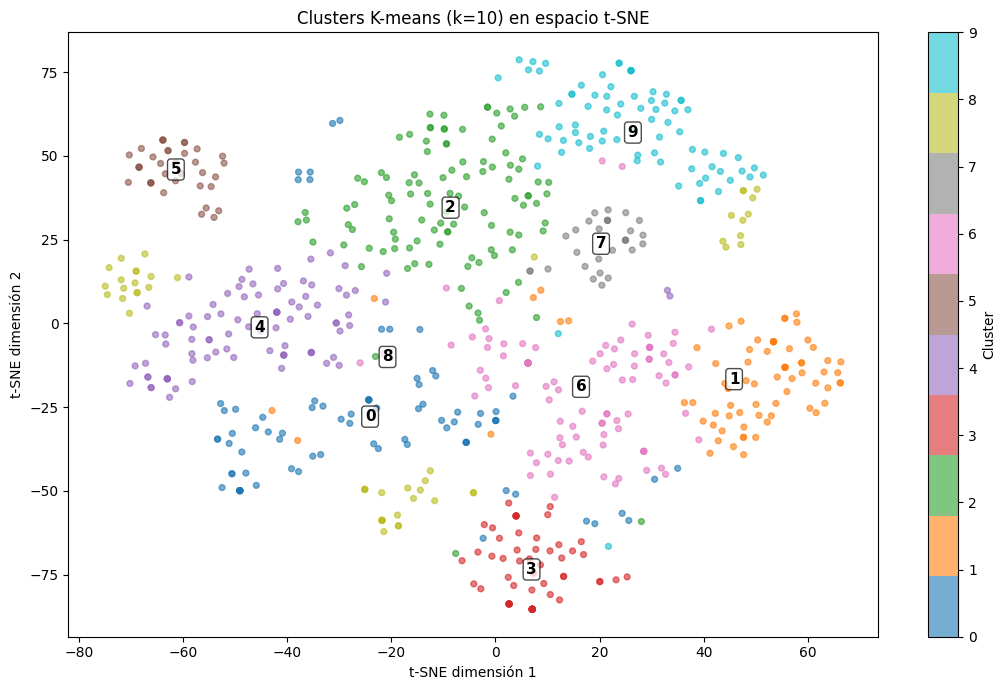

In [34]:
# Visualización 1: t-SNE coloreado por cluster K-means con centroides
fig, ax = plt.subplots(figsize=(11, 7))

scatter = ax.scatter(
    df_con_poder['tsne_x'], df_con_poder['tsne_y'],
    c=df_con_poder['cluster_kmeans'], cmap='tab10',
    alpha=0.6, s=18
)

# Etiquetar el centroide visual de cada cluster
for cluster_id in sorted(df_con_poder['cluster_kmeans'].unique()):
    grupo = df_con_poder[df_con_poder['cluster_kmeans'] == cluster_id]
    cx, cy = grupo['tsne_x'].mean(), grupo['tsne_y'].mean()
    ax.text(cx, cy, str(cluster_id), fontsize=11, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

ax.set_title(f'Clusters K-means (k={k_final}) en espacio t-SNE')
ax.set_xlabel('t-SNE dimensión 1')
ax.set_ylabel('t-SNE dimensión 2')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

**Interpretación:** Cada número indica el centroide visual del cluster. Clusters bien separados en el espacio t-SNE indican que las cartas de ese grupo usan vocabulario claramente distinto. Clusters solapados comparten terminología y pueden representar mecánicas híbridas.

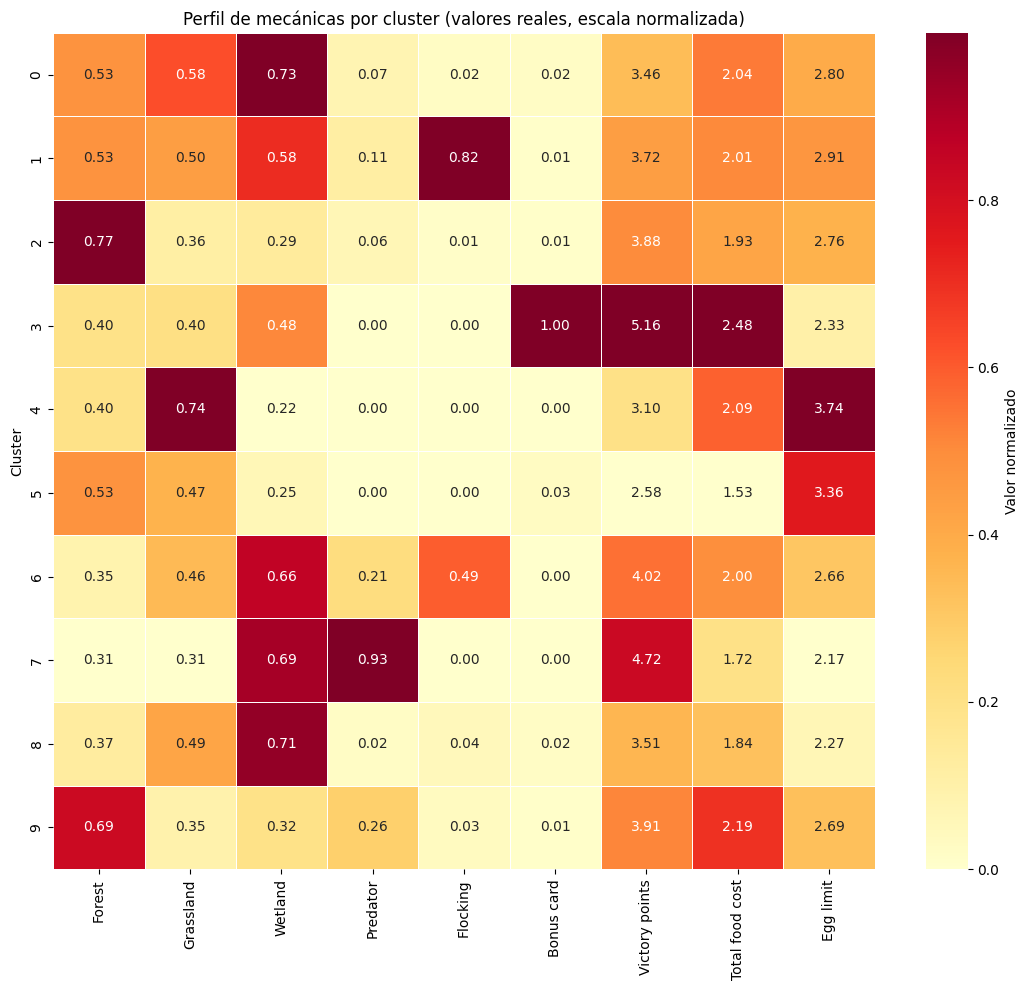

In [35]:
# Visualización 2: heatmap del perfil de mecánicas por cluster
perfil_viz = perfil[[
    'Forest', 'Grassland', 'Wetland',
    'Predator', 'Flocking', 'Bonus card',
    'Victory points', 'Total food cost', 'Egg limit'
]].copy()

# Normalizar cada columna para comparar en la misma escala
perfil_norm = (perfil_viz - perfil_viz.min()) / (perfil_viz.max() - perfil_viz.min() + 1e-9)

fig, ax = plt.subplots(figsize=(11, max(4, k_final)))
sns.heatmap(perfil_norm, annot=perfil_viz.values, fmt='.2f',
            cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Valor normalizado'},
            linewidths=0.5)
ax.set_title('Perfil de mecánicas por cluster (valores reales, escala normalizada)')
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

**Interpretación:** El heatmap muestra en qué mecánicas se diferencia cada cluster. Un cluster con alta proporción de  y  corresponde al motor de cartas; alta  y  al motor de huevos; alta  y bajo costo al motor de alimento. Los valores reales en cada celda permiten comparar magnitudes entre clusters.

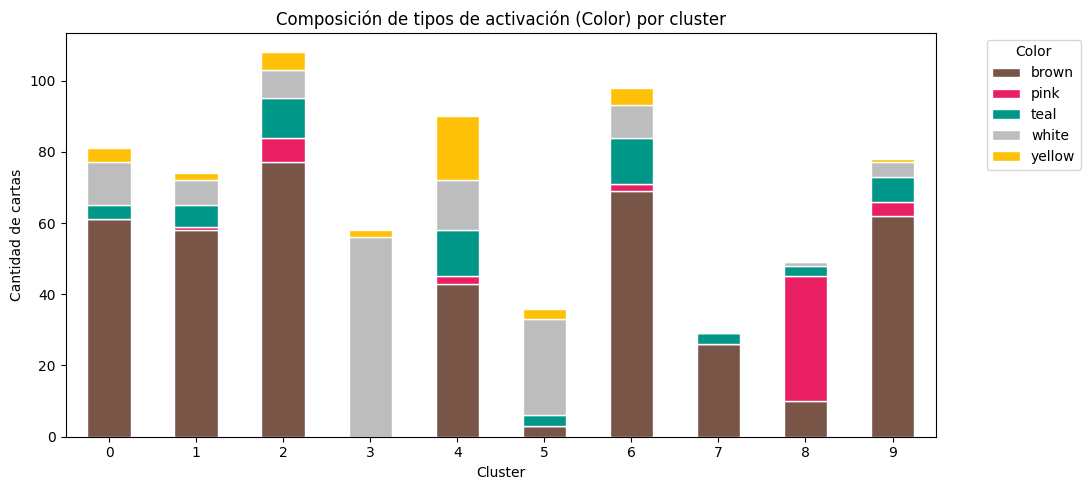

In [36]:
# Visualización 3: distribución de Color por cluster
color_plot = color_por_cluster.drop(columns='Total')
color_col_map = {'brown': '#795548', 'pink': '#E91E63', 'white': '#BDBDBD',
                 'teal': '#009688', 'yellow': '#FFC107'}
bar_colors = [color_col_map.get(str(c).lower(), '#9E9E9E') for c in color_plot.columns]

ax = color_plot.plot(
    kind='bar', stacked=True, figsize=(11, 5),
    color=bar_colors, edgecolor='white'
)
ax.set_title('Composición de tipos de activación (Color) por cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Cantidad de cartas')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Color', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretación:** Si un cluster está dominado por cartas  (poder al activar el hábitat), es el grupo más relevante para construir motores — son las cartas que se encadenan repetidamente. Los clusters con mayoría  (poder al jugar) agrupan cartas de efecto único, menos centrales para un motor sostenido. Un cluster con alta proporción  (una vez entre turnos) identifica cartas de acumulación pasiva.

---
## 4. Conclusiones

*Esta sección se completa en el siguiente commit.*

---
## 5. Uso de IA

*Esta sección se completa en el siguiente commit.*